<a href="https://colab.research.google.com/github/Mandlez/Finance/blob/main/business_case_Macro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Case Markets 360: Cross-Asset Dynamics & Regime-Switching

## 1. Executive Summary & Methodology

**The Objective:** To understand how markets (S&P 500, 10-year U.S. Treasury yields, EUR/USD, USD/BRL) react during periods of strong economic growth compared to periods of slowdown. The ultimate goal is to build and backtest a strategy that capitalizes on these dynamics.

**Our Approach:**
Rather than relying on lagging macroeconomic indicators (such as GDP) or basic moving averages, we have developed a “Quantamental” (Quantitative + Fundamental) framework.
Our core engine is an unsupervised machine learning algorithm: the **Gaussian Hidden Markov Model (Gaussian HMM)**. This model incorporates both leading fundamental indicators (10Y-2Y spread, St. Louis Fed Financial Stress Index) and market data (S&P 500 returns) to dynamically identify shifts in economic regimes, thereby avoiding any look-ahead bias.

In [1]:
!pip install yfinance fredapi hmmlearn statsmodels seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.8 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
from hmmlearn.hmm import GaussianHMM
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

## 2. Data Infrastructure (Data Pipeline)

We are building a robust `DataLoader` class to query the Yahoo Finance API (market data) and the Federal Reserve Bank of St. Louis API (FRED – macroeconomic data).
Public holidays are not aligned between Brazil and the United States, we use a forward-filling method (`fill()`) combined with an inner join to ensure the integrity of our time series before any statistical analysis.

In [3]:
class DataLoader:
    """Manages the collection and alignment of market and macroeconomic data"""

    def __init__(self, fred_api_key: str):
        self.fred = Fred(api_key=fred_api_key)
        self.tickers = {
            'SP500': '^GSPC',
            'US10Y': '^TNX',
            'EURUSD': 'EURUSD=X',
            'USDBRL': 'BRL=X'
        }

    def fetch_market_data(self, start_date: str, end_date: str) -> pd.DataFrame:
        """
        Retrieves historical market data from Yahoo Finance.
        Calculates daily logarithmic returns for price assets and keeps yields raw.

        Args:
            start_date (str): The start date for the data retrieval (YYYY-MM-DD).
            end_date (str): The end date for the data retrieval (YYYY-MM-DD).

        Returns:
            pd.DataFrame: A DataFrame containing returns (for equities/FX) and raw yields (for bonds).
        """
        df_list = []

        for name, ticker in self.tickers.items():
            try:
                # Fetch data from Yahoo Finance API
                data_full = yf.download(ticker, start=start_date, end=end_date)

                # Extract the most relevant price column ('Adj Close' preferred over 'Close')
                if 'Adj Close' in data_full.columns:
                    data = data_full['Adj Close']
                elif 'Close' in data_full.columns:
                    data = data_full['Close']
                else:
                    raise KeyError(f"Neither 'Adj Close' nor 'Close' found for ticker: {ticker}. "
                                   f"Available columns: {data_full.columns.tolist()}")

                # Ensure the extracted data is a 1D Pandas Series prior to concatenation
                if isinstance(data, pd.DataFrame):
                    data = data.iloc[:, 0]

                data.name = name
                df_list.append(data)

            except Exception as e:
                print(f"Error fetching data for {name} ({ticker}): {e}")
                raise

        # Concatenate all individual series into a single DataFrame
        market_df = pd.concat(df_list, axis=1)

        # Explicitly rename columns to match the human-readable keys defined in self.tickers
        market_df.columns = list(self.tickers.keys())

        # Handle misaligned trading days (e.g., US vs. Brazil holidays) using forward fill
        market_df = market_df.ffill().dropna()

        # Separate Price Returns from Yields
        price_assets = ['SP500', 'EURUSD', 'USDBRL']
        returns = market_df[price_assets].pct_change()

        # For yields (US10Y), we keep the raw percentage value, as converting it to a log return
        # mathematically distorts its volatility.
        returns['US10Y'] = market_df['US10Y']

        return returns.dropna()

    def fetch_macro_data(self, start_date: str) -> pd.DataFrame:
        """Retrieves the FRED macro indicators (10-year/2-year spread and Stress Index)"""
        # T10Y2Y = Spread 10Y - 2Y  (Leading Recession Indicator)
        # STLFSI4 = St. Louis Fed Financial Stress Index
        spread = self.fred.get_series('T10Y2Y', observation_start=start_date)
        stress = self.fred.get_series('STLFSI4', observation_start=start_date)

        macro_df = pd.DataFrame({'Yield_Spread': spread, 'Stress_Index': stress})
        # FRED data may have different frequencies (daily vs. weekly)
        return macro_df.ffill().dropna()

# Execution
# Note: For a production environment, this key would be securely loaded via os.getenv('FRED_API_KEY')
loader = DataLoader(fred_api_key='a76b76f5d7247021507765d5f7cd9076')
returns_df = loader.fetch_market_data('2010-01-01', '2026-04-30')
macro_df = loader.fetch_macro_data('2010-01-01')

# Final data alignment
data = returns_df.join(macro_df, how='inner').dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 3. Preliminary Statistical Analysis

Before deploying our predictive model, we assess the behavior of our assets over the entire period using a **Pearson correlation matrix** and an **annualized covariance matrix**.
This step allows us to validate certain basic macroeconomic insights (e.g., the role of the U.S. dollar as a safe-haven asset relative to risky assets and emerging market currencies).

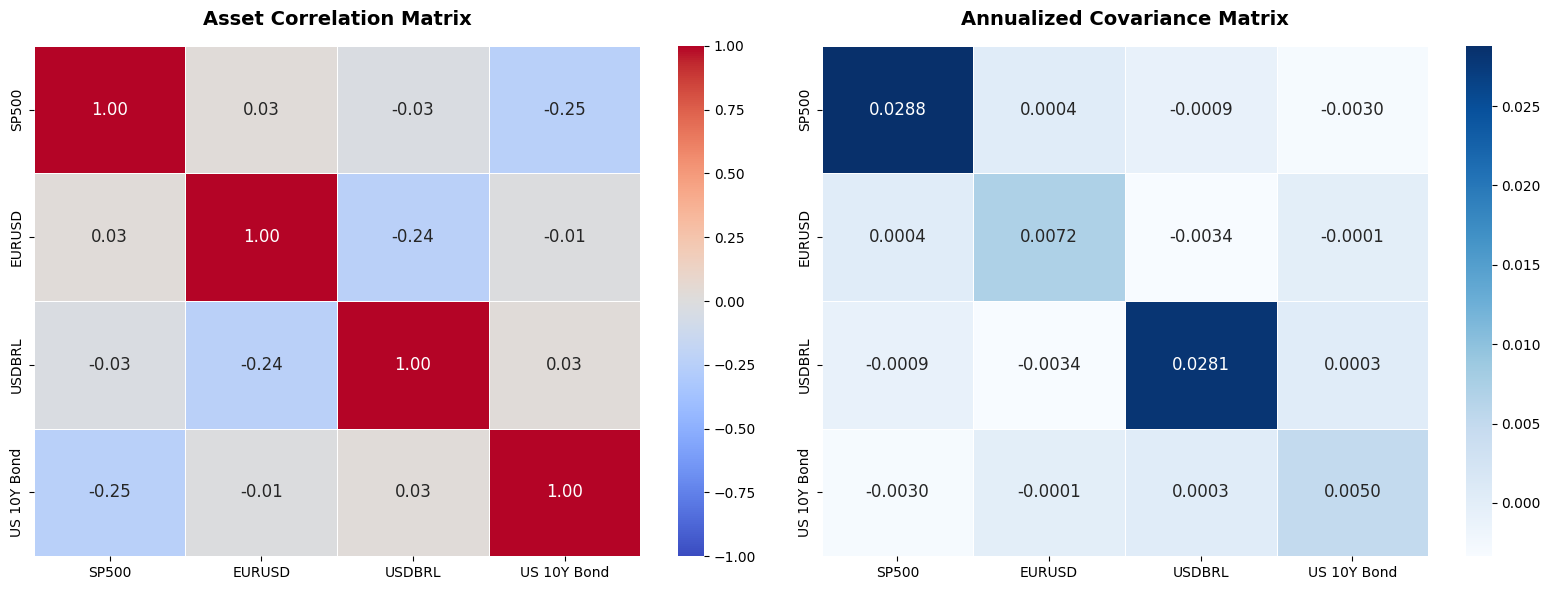

In [4]:
class PreliminaryAnalyzer:
    """Analyzes preliminary statistics, correlations, and covariances of financial assets."""

    def __init__(self, df: pd.DataFrame):
        # Select the relevant columns and create a copy to avoid SettingWithCopyWarning
        self.returns = df[['SP500', 'US10Y', 'EURUSD', 'USDBRL']].copy()

        # YIELD TO PRICE RETURN
        # The US10Y data represents a yield. Treating a yield's relative change as a price return
        # mathematically overstates its volatility (e.g., creating 40%+ annualized volatility).
        # We transform it into an approximate Bond Return using Modified Duration.
        duration_10y = 8.5
        yield_decimal = self.returns['US10Y'] / 100

        # Approximate Bond Return: Accrued Yield - (Duration * Yield Change)
        self.returns['US10Y_Bond'] = (yield_decimal / 252) - (duration_10y * yield_decimal.diff())

        # Drop the raw yield column and keep the Bond returns for a coherent matrix analysis
        self.returns = self.returns.drop(columns=['US10Y']).dropna()

        # Rename for cleaner chart labels
        self.returns = self.returns.rename(columns={'US10Y_Bond': 'US 10Y Bond'})

    def plot_matrices(self):
        """Displays heatmaps for both correlation and annualized covariance side-by-side."""
        # Calculate correlation and annualized covariance
        corr_matrix = self.returns.corr()
        cov_matrix_annual = self.returns.cov() * 252

        # Create a figure with 1 row and 2 columns
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # --- Figure 1: Correlation (on axes[0]) ---
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                    fmt='.2f', linewidths=0.5, annot_kws={"size": 12}, ax=axes[0])
        axes[0].set_title('Asset Correlation Matrix', fontsize=14, fontweight='bold', pad=15)

        # --- Figure 2: Annualized Covariance (on axes[1]) ---
        sns.heatmap(cov_matrix_annual, annot=True, cmap='Blues',
                    fmt='.4f', linewidths=0.5, annot_kws={"size": 12}, ax=axes[1])
        axes[1].set_title('Annualized Covariance Matrix', fontsize=14, fontweight='bold', pad=15)

        # Adjust the spacing so that nothing overlaps
        plt.tight_layout()
        plt.show()

# --- Execution ---
# Ensure 'data' contains the raw downloaded metrics
prelim_analyzer = PreliminaryAnalyzer(data)
prelim_analyzer.plot_matrices()

## 4. Dynamic Detection of Economic Regimes (HMM Model)

To answer the question: *“How do you assess economic slowdowns?”*, we use our Hidden Markov Model (HMM).
Since financial and macroeconomic time series exhibit highly heterogeneous scales and variances (rates in % versus daily returns in tenths of a %), **normalization (Z-score scaling via `StandardScaler`) is an essential mathematical step** to ensure the convergence of the HMM’s Expectation-Maximization algorithm.

The model thus classifies our historical data into two “hidden states” (State 0 and State 1), which we then empirically identify as periods of ‘Growth’ or “Slowdown/Stress.”

In [5]:
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

class QuantamentalRegimeDetector:
    """
    Deploys a Gaussian Hidden Markov Model (HMM) to detect underlying economic regimes
    using normalized market and fundamental features.
    """

    def __init__(self, n_components: int = 2):
        # n_components = 2 representing Strong Growth vs. Economic Slowdown
        self.model = GaussianHMM(
            n_components=n_components,
            covariance_type="full",
            n_iter=2000,     # Increased iterations to ensure mathematical convergence
            tol=0.001,       # Tolerance threshold for the EM algorithm
            random_state=42
        )
        self.scaler = StandardScaler() # Crucial tool for Z-score normalization

    def fit_predict(self, df: pd.DataFrame, features: list) -> pd.Series:
        """
        Scales the input features, fits the HMM, and predicts the hidden regimes.

        Args:
            df (pd.DataFrame): The dataset containing the features.
            features (list): List of column names to be used as model inputs.

        Returns:
            pd.Series: The predicted regime labels (0 or 1) aligned with the dataframe index.
        """
        # 1. Extract raw features
        X_raw = df[features].values

        # 2. Z-score normalization - CRUCIAL STEP FOR HMM CONVERGENCE
        # HMMs are highly sensitive to unscaled variance (e.g., yields vs. log returns)
        X_scaled = self.scaler.fit_transform(X_raw)

        # 3. Fit the model and predict using scaled data
        self.model.fit(X_scaled)

        # Convergence check
        if self.model.monitor_.converged:
            print(f"Model successfully converged in {self.model.monitor_.iter} iterations.")
        else:
            print("Warning: The HMM did not converge.")

        regimes = self.model.predict(X_scaled)
        return pd.Series(regimes, index=df.index, name='Regime')

# Execution
detector = QuantamentalRegimeDetector(n_components=2)

features_hmm = ['SP500', 'Yield_Spread', 'Stress_Index']

# Apply the model to generate regime signals
data['Regime'] = detector.fit_predict(data, features_hmm)

# Quick display of regime distribution
print("\nDays distribution per regime:")
print(data['Regime'].value_counts())

# Calculate and display annualized mean returns per regime to map 0 and 1 to economic reality
regime_stats = data.groupby('Regime')[['SP500', 'US10Y', 'EURUSD', 'USDBRL']].mean() * 252
print("\n--- Annualized Mean Returns per Regime ---")
display(regime_stats.style.background_gradient(cmap='RdYlGn'))

Model successfully converged in 38 iterations.

Days distribution per regime:
Regime
0    2795
1    1458
Name: count, dtype: int64

--- Annualized Mean Returns per Regime ---


,SP500,US10Y,EURUSD,USDBRL
Regime,,,,
0,0.144410,722.817956,-0.007720,0.044792
1,0.083415,552.203901,-0.010657,0.139368


## 5. Asset Dynamics and Advanced Information (Lead-Lag)

The static correlations calculated earlier are useful, but they are not sufficient to build a trading strategy. We need to understand whether one asset leads the others and whether these relationships remain stable over time.

1. **Lead-Lag Information:** We use the **Granger Causality Test** to statistically prove (via *p-value* analysis) that movements in the bond market (US 10Y) contain predictive information about the foreign exchange market (EUR/USD).
2. **Time Series Analysis:** We generate a **rolling correlation** chart between the S&P 500 and the USDBR, onto which we overlay the “Stress/Slowdown” periods identified by our HMM model. This visually illustrates the fundamental concept of *correlation breakdown during times of crisis*.


--- Test: Does US10Y lead EURUSD? ---
Lag 1 days: p-value = 0.8442 
Lag 2 days: p-value = 0.0000 ***
Lag 3 days: p-value = 0.0000 ***
Lag 4 days: p-value = 0.0000 ***
Lag 5 days: p-value = 0.0000 ***
Note: *** p<0.01 (Strong), ** p<0.05 (Moderate), no star = Not significant.

--- Test: Does EURUSD lead US10Y? ---
Lag 1 days: p-value = 0.2540 
Lag 2 days: p-value = 0.4362 
Lag 3 days: p-value = 0.7518 
Lag 4 days: p-value = 0.6119 
Lag 5 days: p-value = 0.2062 
Note: *** p<0.01 (Strong), ** p<0.05 (Moderate), no star = Not significant.


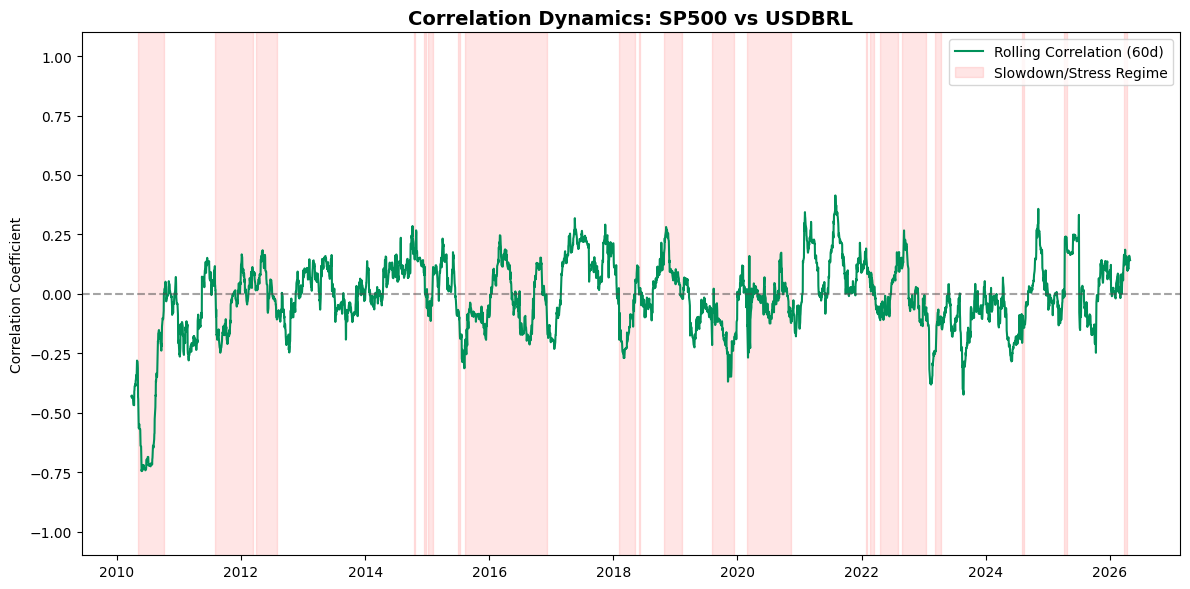

In [6]:
class LeadLagAnalyzer:
    """Analyzes causality relationships and dynamic correlations between assets."""

    def __init__(self, df: pd.DataFrame):
        self.data = df

    def granger_test(self, target: str, predictor: str, maxlag: int = 5):
        """
        Tests whether the 'predictor' helps forecast the 'target'.

        Note: The grangercausalitytests function takes columns in the order [Y, X]
        to test if X Granger-causes Y.
        """
        print(f"\n--- Test: Does {predictor} lead {target}? ---")

        # Ensure there are no missing values (NaNs) before testing
        test_data = self.data[[target, predictor]].dropna()

        # Set verbose=False to hide the default cluttered statsmodels output
        gc_res = grangercausalitytests(test_data, maxlag=maxlag, verbose=False)

        # Clean extraction of the p-values from the F-test
        for lag in range(1, maxlag + 1):
            p_value = gc_res[lag][0]['ssr_ftest'][1]
            significance = "***" if p_value < 0.01 else ("**" if p_value < 0.05 else "")
            print(f"Lag {lag} days: p-value = {p_value:.4f} {significance}")

        print("Note: *** p<0.01 (Strong), ** p<0.05 (Moderate), no star = Not significant.")

    def plot_rolling_correlation(self, asset1: str, asset2: str, window: int = 60, regimes: pd.Series = None):
        """Plots the rolling correlation and overlays economic regimes if provided."""

        # Define color constants locally for this function
        BNP_GREEN = '#00915a'
        DARK_GREY = '#4a4a4a'

        # Calculate the rolling correlation
        corr = self.data[asset1].rolling(window=window).corr(self.data[asset2])

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(corr.index, corr, color=BNP_GREEN, linewidth=1.5, label=f'Rolling Correlation ({window}d)')
        ax.axhline(0, color=DARK_GREY, linestyle='--', alpha=0.5)

        # Overlay periods of economic slowdown/stress
        if regimes is not None:
            # Assuming state 1 represents the slowdown/stress regime (based on HMM outputs)
            stress_periods = regimes == 1
            ax.fill_between(corr.index, -1, 1, where=stress_periods,
                            color='red', alpha=0.1, label='Slowdown/Stress Regime',
                            transform=ax.get_xaxis_transform())

        ax.set_title(f'Correlation Dynamics: {asset1} vs {asset2}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Correlation Coefficient')
        ax.set_ylim(-1.1, 1.1)
        ax.legend(loc='upper right')

        plt.tight_layout()
        plt.show()

#Execution
analyzer = LeadLagAnalyzer(data)

# 1. Test: Do US 10-year yields lead the EURUSD?
# Macro theory: Changes in US yields alter the interest rate differential, driving capital flows.
analyzer.granger_test(target='EURUSD', predictor='US10Y', maxlag=5)

# 2. Reverse test for robustness check (Does EURUSD lead US yields?)
# Often, this test yields weaker results, confirming that yields lead the currency, not the reverse.
analyzer.granger_test(target='US10Y', predictor='EURUSD', maxlag=5)

# 3. Visual: How does the S&P500 / USDBRL relationship evolve across regimes?
# Macro theory: In a crisis, the S&P500 drops and the USD rallies (safe haven), causing USDBRL to rise.
# The correlation should turn highly negative during stress regimes.
analyzer.plot_rolling_correlation(asset1='SP500', asset2='USDBRL', window=60, regimes=data['Regime'])

## 6. Portfolio Construction and Backtesting (Reality Check)

Based on the insights from our model, we design a systematic “Regime-Switching” strategy:
*   **In Growth Regime:** Long exposure to the S&P 500 (capturing the equity risk premium).
*   **In Slowdown/Stress Regime:** Implementation of a hedge via a “Short S&P 500 / Long USDBRL” position.

**Institutional robustness criteria implemented:**
1.  **Signal lag (`shift(1)`)**: Strict elimination of any look-ahead bias. Signals generated at the end of day $T$ are executed only on day $T+1$.
2.  **Transaction costs:** Addition of a friction cost of 5 basis points (0.05%) to each portfolio rebalancing, reflecting real-market constraints.
3.  **Multi-Class Comparison:** Performance is evaluated not only against the absolute return of the S&P 500, but also against relevant benchmarks: a cash proxy (USD Cash) and the standard asset allocation, the **60/40 Cross-Asset Portfolio**. We simulate the strategy in the form of an “Overlay” (50% Core Equity / 50% Strategy).

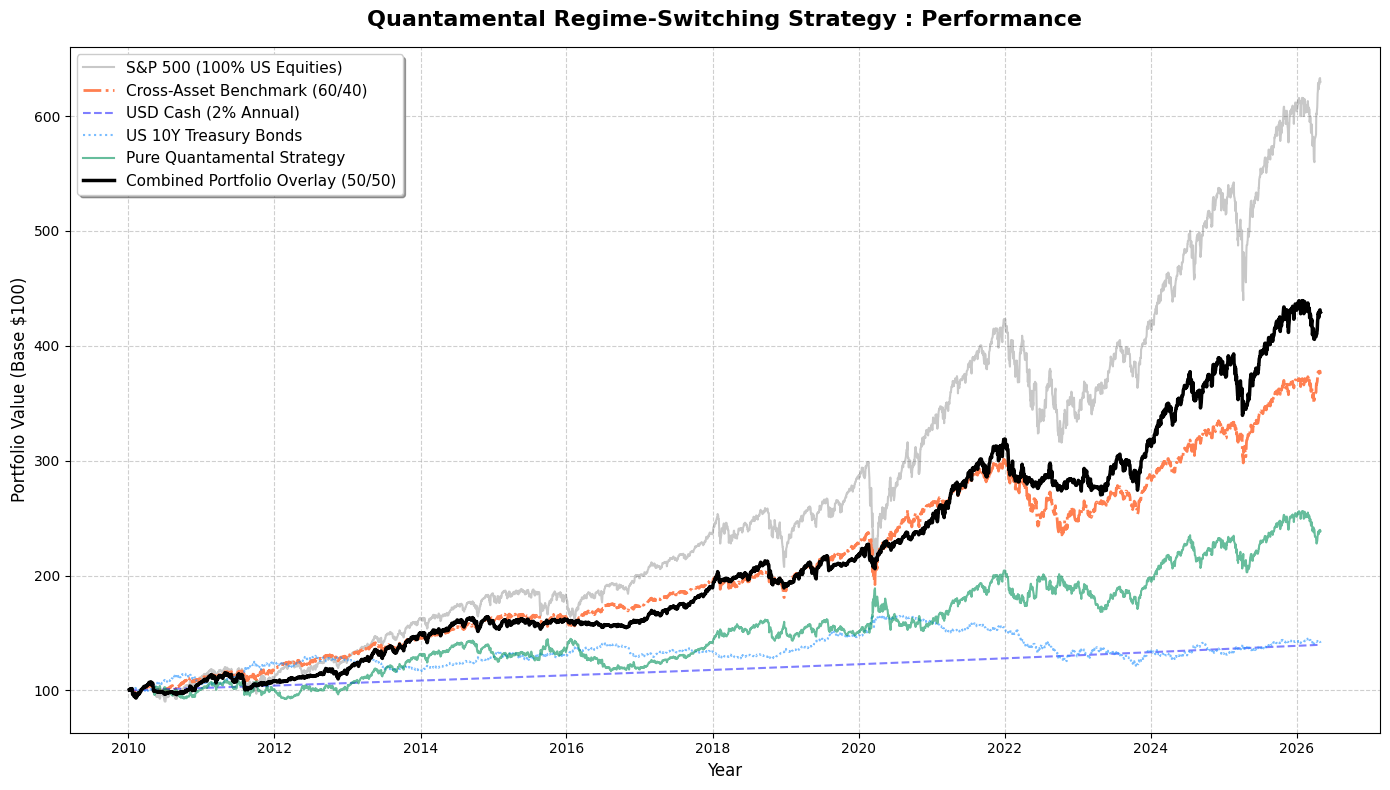


  EXECUTIVE SUMMARY : RISK & PERFORMANCE METRICS


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
S&P 500 (Buy & Hold),13.14%,16.97%,0.77,-33.92%
Benchmark 60/40,8.69%,9.86%,0.88,-21.89%
Pure Strategy (Net),6.23%,13.40%,0.47,-19.73%
Mixed Portfolio (50/50),9.63%,10.65%,0.90,-15.24%


In [8]:
import matplotlib.ticker as ticker

class AdvancedBacktester:
    """Simulates the quantamental strategy, overlay, and compares against institutional benchmarks."""

    def __init__(self, df: pd.DataFrame):
        self.data = df.copy()
        self._assign_regime_labels()

    def _assign_regime_labels(self):
        """Automatically identifies the slowdown regime (where SP500 returns are lowest)."""
        mean_returns = self.data.groupby('Regime')['SP500'].mean()
        self.slowdown_regime = mean_returns.idxmin()
        self.growth_regime = 1 - self.slowdown_regime

    def run_strategy(self, tc_rate: float = 0.0005):
        """Executes the strategy considering transaction costs (5 bps)."""
        # 1. Passive Benchmarks
        self.data['Benchmark_SP500'] = self.data['SP500']
        self.data['Benchmark_Cash'] = (1 + 0.02) ** (1/252) - 1 # Proxy Cash 2% annual yield

        # Bond Returns (US 10Y via Duration Approximation)
        duration_10y = 8.5
        yield_decimal = self.data['US10Y'] / 100
        self.data['Bond_Returns'] = (yield_decimal / 252) - (duration_10y * yield_decimal.diff())
        self.data['Bond_Returns'] = self.data['Bond_Returns'].fillna(0)

        # The institutional benchmark: 60/40 Cross-Asset Portfolio
        self.data['Benchmark_60_40'] = (0.6 * self.data['Benchmark_SP500']) + (0.4 * self.data['Bond_Returns'])

        # 2. Signals and Gross Returns (1-day lag to avoid look-ahead bias)
        self.data['Signal_Regime'] = self.data['Regime'].shift(1)
        self.data['Strategy_Returns_Gross'] = np.where(
            self.data['Signal_Regime'] == self.growth_regime,
            self.data['SP500'],
            (-0.5 * self.data['SP500']) + (0.5 * self.data['USDBRL'])
        )

        # 3. Application of transaction costs (Portfolio Rebalancing)
        self.data['Signal_Change'] = (self.data['Signal_Regime'].diff().fillna(0) != 0).astype(int)
        self.data['Strategy_Returns_Net'] = self.data['Strategy_Returns_Gross'] - (self.data['Signal_Change'] * tc_rate)

        # 4. Combined / Overlay Portfolio (50% Core Equity + 50% Quantamental Satellite)
        self.data['Combined_Portfolio'] = (0.5 * self.data['Benchmark_SP500']) + (0.5 * self.data['Strategy_Returns_Net'])

        # 5. Calculate cumulative performances (Base 100)
        cols_to_cumulate = ['Benchmark_SP500', 'Benchmark_60_40', 'Strategy_Returns_Net', 'Combined_Portfolio', 'Benchmark_Cash', 'Bond_Returns']
        for col in cols_to_cumulate:
            self.data[f'Cum_{col}'] = 100 * (1 + self.data[col]).cumprod()

    def display_risk_metrics(self):
        """Calculates and displays a highly formatted, client-ready risk metrics table."""
        metrics = {}
        portfolios = {
            'S&P 500 (Buy & Hold)': 'Benchmark_SP500',
            'Benchmark 60/40': 'Benchmark_60_40',
            'Pure Strategy (Net)': 'Strategy_Returns_Net',
            'Mixed Portfolio (50/50)': 'Combined_Portfolio'
        }

        for name, col in portfolios.items():
            returns = self.data[col].dropna()
            ann_ret = (1 + returns.mean()) ** 252 - 1
            ann_vol = returns.std() * np.sqrt(252)
            sharpe = ann_ret / ann_vol if ann_vol != 0 else 0

            cum_rets = (1 + returns).cumprod()
            rolling_max = cum_rets.cummax()
            drawdowns = cum_rets / rolling_max - 1
            max_dd = drawdowns.min()

            metrics[name] = {
                'Ann. Return': f"{ann_ret*100:.2f}%",
                'Ann. Volatility': f"{ann_vol*100:.2f}%",
                'Sharpe Ratio': f"{sharpe:.2f}",
                'Max Drawdown': f"{max_dd*100:.2f}%"
            }

        df_metrics = pd.DataFrame(metrics).T

        def highlight_strategy(s):
            if s.name == 'Mixed Portfolio (50/50)':
                return ['background-color: #e6f2ec; font-weight: bold; color: black'] * len(s)
            return ['background-color: white; color: black'] * len(s)

        styled_table = df_metrics.style.apply(highlight_strategy, axis=1) \
            .set_properties(**{'text-align': 'center', 'border': '1px solid #d3d3d3', 'padding': '10px'}) \
            .set_table_styles([
                {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('text-align', 'center'), ('font-size', '14px')]},
                {'selector': 'th.row_heading', 'props': [('background-color', '#f4f4f4'), ('color', 'black'), ('text-align', 'left')]}
            ])

        print("\n" + "="*50)
        print("  EXECUTIVE SUMMARY : RISK & PERFORMANCE METRICS")
        print("="*50)
        display(styled_table)

    def plot_results(self):
        """Generates the institutional performance chart (Equity Curve only)."""
        BNP_GREEN = '#00915a'
        DARK_GREY = '#4a4a4a'

        fig, ax = plt.subplots(figsize=(14, 8))

        # Benchmarks
        ax.plot(self.data.index, self.data['Cum_Benchmark_SP500'], label='S&P 500 (100% US Equities)', color=DARK_GREY, alpha=0.3, linewidth=1.5)
        ax.plot(self.data.index, self.data['Cum_Benchmark_60_40'], label='Cross-Asset Benchmark (60/40)', color='coral', linestyle='-.', linewidth=2)

        # Cash & Bonds
        ax.plot(self.data.index, self.data['Cum_Benchmark_Cash'], label='USD Cash (2% Annual)', color='blue', linestyle='--', alpha=0.5, linewidth=1.5)
        ax.plot(self.data.index, self.data['Cum_Bond_Returns'], label='US 10Y Treasury Bonds', color='dodgerblue', linestyle=':', alpha=0.6, linewidth=1.5)

        # Strategies
        ax.plot(self.data.index, self.data['Cum_Strategy_Returns_Net'], label='Pure Quantamental Strategy', color=BNP_GREEN, linewidth=1.5, alpha=0.6)
        ax.plot(self.data.index, self.data['Cum_Combined_Portfolio'], label='Combined Portfolio Overlay (50/50)', color='black', linewidth=2.5)

        ax.set_title('Quantamental Regime-Switching Strategy : Performance', fontsize=16, fontweight='bold', pad=15)
        ax.set_ylabel('Portfolio Value (Base $100)', fontsize=12)
        ax.set_xlabel('Year', fontsize=12)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
        ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
        ax.grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()

# Final Execution
bt = AdvancedBacktester(data)
bt.run_strategy(tc_rate=0.0005)
bt.plot_results()
bt.display_risk_metrics()

## 7. Model Limitations & Future Work: The Case for Copulas

While the current Quantamental framework successfully captures regime shifts, it relies on rolling Pearson correlations to evaluate the dynamic relationship between assets (e.g., S&P 500 and USDBRL).

**The Limitation:** Pearson correlation measures linear dependence and treats positive and negative shocks symmetrically. However, in financial markets, asset dependence is notoriously asymmetric: assets tend to crash together but do not necessarily rally together.

**Next Steps (Copulas):** To make this strategy robust for a live trading environment, the next iteration should replace Pearson correlation with **Statistical Copulas** (such as the Clayton Copula). Copulas allow us to isolate the marginal distributions of the assets and specifically model their **Lower Tail Dependence** (the probability that the S&P 500 and USDBRL crash simultaneously). This would allow for a much more accurate and dynamic sizing of our hedge ratios during economic stress regimes.